<img src="assets/OFE-color-horizontal.png" width="300">

# Running a relative binding free energy campaign with OpenFE

*OpenFE: CCPBiosim 2026 Training Week — 2nd October 2026.*

In this notebook we demonstrate how you can use [OpenFE](https://openfree.energy/) to plan,
set up, run, and analyse a relative binding free energy (RBFE) campaign for a series of congeneric
ligands. First with the OpenFE command line interface (CLI) using OpenFE's recommended defaults,
and then using the Python API to build a more customised campaign.

By the end of this tutorial you will be able to:

- Explain the core concepts of a hybrid topology RBFE calculation.
- Plan an entire RBFE campaign using OpenFE's CLI commands.
- Use the OpenFE Python API to build a custom campaign: choosing your own atom mapper, network
  topology, protocol settings, and partial charge method.
- Know where to look to run and analyse the resulting simulations.

For more information on how to use OpenFE, we refer you to:

- The [OpenFE documentation](https://docs.openfree.energy/en/stable/). We particularly recommend the OpenFE [tutorials](https://docs.openfree.energy/en/stable/tutorials/index.html), [cookbooks](https://docs.openfree.energy/en/stable/cookbook/index.html), and [user guide](https://docs.openfree.energy/en/stable/guide/index.html).
- The [OpenFE discussions board](https://github.com/orgs/OpenFreeEnergy/discussions).
- The [OpenFE source code](https://github.com/OpenFreeEnergy/openfe).

We also recommend the following literature:
- Mey et al., ["Best Practices for Alchemical Free Energy Calculations"](https://livecomsjournal.org/index.php/livecoms/article/view/v2i1e18378), Living J. Comp. Mol. Sci. (2020)
- Baumann et al., [Large-Scale Collaborative Assessment of Binding Free Energy Calculations for Drug Discovery Using OpenFE](https://pubs.acs.org/jcisd8/article-abstract/66/11/6429/5185029/Large-Scale-Collaborative-Assessment-of-Binding?redirectedFrom=fulltext), J. Chem. Inf. Model. (2026)

## Overview

| Section | What we'll cover |
|:---|:---|
| Background: the system | The MCL-1 protein and ligand series we'll be working with |
| Background: hybrid topology RBFEs | Key details about hybrid topology calculations |
| The OpenFE CLI | Planning and running an entire campaign using the OpenFE command line interface |
| The OpenFE Python API | Building a fully custom campaign using OpenFE's Python API |
| Review & Conclusions | Recap, and where to go next |

## Background: the system

Throughout this tutorial we will be working with a congeneric series of fragments binding to **MCL-1**.
This dataset originates from a study by Friberg et al., *J. Med Chem.*, 2013 and was subsequently used as a
binding free energy benchmark in Steinbrecher et al., *J. Chem. Inf. Model.* 2015.

We are using this example set because it involves reasonably small system sizes and simple transformations
which are easy to converge.

The dataset inputs live under `./inputs`, and include:

- `ligands.sdf`: 14 small fragment ligands, all **pre-aligned to a common binding pose** (this
  matters for hybrid topology, see below!).
- `protein.pdb`: the MCL-1 receptor. *Note: whilst this PDB file does not contain any ions or co-crystal waters, these can be handled by OpenFE.*

Let's start by looking at the ligands. To do this, we load the contents of the SDF file into [RDKit](https://www.rdkit.org/).

Loaded 14 ligands


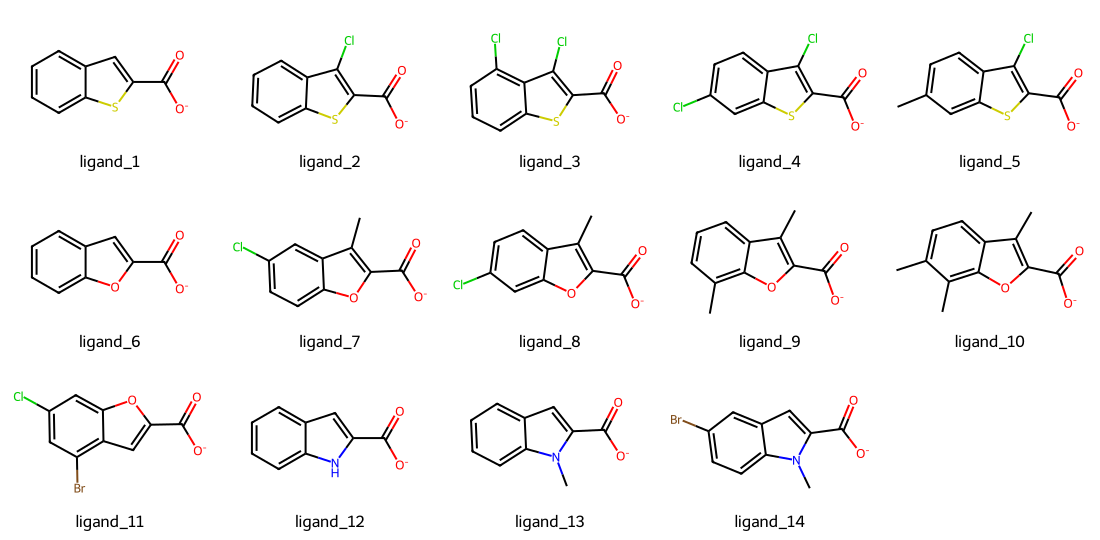

In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import MolsToGridImage

# First we load the ligands - we remove hydrogens to make it easier to visualize
supplier = Chem.SDMolSupplier("inputs/ligands.sdf", removeHs=True)
ligand_rdmols = list(supplier)
print(f"Loaded {len(ligand_rdmols)} ligands")

# Next we generate new 2D structures - the file already contains 3D conformations
# but these are hard to depict in 2D
for mol in ligand_rdmols:
    AllChem.Compute2DCoords(mol)

# Finally, we depict the ligands in 2D
MolsToGridImage(
    ligand_rdmols,
    legends=[mol.GetProp("_Name") for mol in ligand_rdmols],
    molsPerRow=5,
    subImgSize=(220, 180),
)

These are fragment-sized modifications of one another — small substituent swaps rather than
wholesale scaffold changes — which is exactly the kind of series hybrid topology RBFE handles well.

Let's also look at what one of these ligands looks like bound to the protein:

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**

Here are the main py3dmol mouse commands:
- **left button** rotate the model
- **middle button** translate the model
- **scroll wheel** zoom in and out.

</div>

In [2]:
# First we reload our ligand molecules to get their original 3D conformations
from rdkit import Chem

supplier = Chem.SDMolSupplier("inputs/ligands.sdf", removeHs=True)
ligand_rdmols = list(supplier)

In [3]:
# Then we load everything into py3dmol for visualization
import py3Dmol

view = py3Dmol.view(width=600, height=400)

# Load in the protein
with open("inputs/protein.pdb") as f:
    view.addModel(f.read(), "pdb")

# Load in the ligand
example_ligand = ligand_rdmols[0]
view.addModel(Chem.MolToMolBlock(example_ligand), "mol")

# Set the protein (model 0) style to cartoon and the binding site residues to stick
# Set the ligand (model 1) style to stick
view.setStyle({"model": 0}, {"cartoon": {"colorscheme": "lightgrey"}})
view.setStyle({"model": 0, "resi": ["57-61", "80-84", "93-100"]}, {'stick': {"colorscheme": "cyan"}})
view.setStyle({"model": 1}, {"stick": {"colorscheme": "cyanCarbon"}})

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

<div style="background-color:#e8f5e9; border-left: 6px solid #4caf50; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

✏️ **Exercise**


Play around with visualizing the different ligands in the set.
You can do this by changing the line `example_ligand = ligand_rdmols[0]` in the cell above to index a new entry in the list of ligands.
For example: `example_ligand = ligand_rdmols[2]` for the 3rd ligand.

</div>

## Background: hybrid topology binding free energies

### The relative binding free energy (RBFE) thermodynamic cycle

Rather than simulating each ligand's binding free energy in isolation (which converges very slowly), we compute the
*relative* binding free energy, ΔΔG, between pairs of similar ligands using a thermodynamic cycle:

<center> <img src="assets/rbfe_thermocycle.png" width="500"> </center>

Because this cycle is closed, we don't need to compute either of the (very hard to converge)
horizontal legs directly. Instead we simulate the vertical legs to get the relative free energy (ΔΔG).

```
ΔΔG_bind(A→B) = ΔG_bind(B) − ΔG_bind(A) = ΔG_complex(A→B) − ΔG_solvent(A→B)
```

Each vertical leg is an **alchemical transformation**: which involves simulating the
mutation of ligand A into ligand B in a given environment and then estimating the free
energy of that transformation. This means every ligand pair in an RBFE campaign requires **two** simulations: one with
the ligand transforming in solvent, and one with it transforming in the
protein-bound complex.

### The hybrid topology scheme

There are many different ways of treating the interpolation of two end states in an alchemical simulation. Examples include single topology schemes (e.g. Transformato by Karwounopoulos et al., *Front. Mol. Biosci.*, 2022), dual coordinate / topology schemes (e.g. Separated Topologies by Baumann et al., *J. Chem. Theory Comput.*, 2023), and hybrid topology schemes as is used in OpenFE. These mostly differ in the way in which the atoms are made to appear and disappear.

As previously mentioned, OpenFE by default uses a **hybrid topology** scheme for relative free energies.
In this approach, both end-state ligands are described within a single "combined" molecule: atoms common
to both ligands (the "core") are simply interpolated, while atoms unique to either end state are grown in
or removed as dummy atoms over the course of the simulation. Because only the non-common atoms are perturbed,
these transformations are usually much smaller, and therefore much cheaper to converge, than perturbing complete
molecules (e.g. in absolute calculations or Separated Topologies).

<center>
    <img src="assets/hybrid_topology.png" width="500">
    <figcaption align = "center"> Hybrid Topology Scheme, reproduced from the <a href="https://www.alchemistry.org/wiki/Constructing_a_Pathway_of_Intermediate_States">alchemistry wiki</a> </figcaption>
</center>
<br>
Despite its advantages, hybrid topology calculations come with some trade-offs:

- **You need a common core.** Ligands must share a reasonable amount of chemical scaffold for a
  sensible hybrid topology mapping to exist. This means that you can't use this method to look
  at free energy difference between ligands with completely different chemical scaffolds. In those
  cases you would need a method like [Separated Topology](https://docs.openfree.energy/en/stable/guide/protocols/septop/septop_overview.html) instead.
- **Ligands must be aligned on their common core.** The common core must occupy very similar positions
  between the two end states. Atom mappers such as [Kartograf](https://github.com/OpenFreeEnergy/kartograf)
  inherently make this assumption and will fail to map ligand pairsr which are not aligned. This is why
  our input ligands in `ligands.sdf` are all pre-aligned on a common pose.
- **It isn't a formally exact method.** Handling dummy atoms introduces some approximations that
  can occasionally bias the free energy estimate (see [Fleck et al., *J. Chem. Theory Comput.*, 2021](https://pmc.ncbi.nlm.nih.gov/articles/PMC8280730/)
  for more information on dummy-atom artefacts in alchemical calculations). In
  practice, though, hybrid topology RBFEs are still very accurate, substantially more so than
  end-point methods like MM-GBSA, as shown in OpenFE's own large-scale benchmarking study
  ([Baumann et al., *J. Chem. Inf. Model.*, 2026](https://pubs.acs.org/jcisd8/article/66/11/6429/5185029/Large-Scale-Collaborative-Assessment-of-Binding)).

### Workflow of an RBFE campaign

In OpenFE, an RBFE campaign (i.e. calculating RBFEs over a large set of ligands of interest), usually follows this workflow:

<br>
<br>
<center>
    <img src="assets/free_energy_campaign.png" width="700">
    <figcaption align = "center"> Key components of an RBFE campaign </figcaption>
</center>
<br>
<br>

Here is a brief description of each stage:
- **Process inputs**: this involves loading relevant input files (e.g. our `ligands.sdf` and `protein.pdb`), and processing them e.g.
  adding partial charges to our ligands.
- **Create a network of mappped ligand pairs**: to run relative binding free energies, we need to know a) what transformations we should
  simulate, and b) the atom correspondence between the mutating ligands (e.g. which atoms will be appearing & disappearing). Ideally we
  attempt to simulate every single possible pair of ligands, but doing so would be prohebitively expensive. Instead we select a subset of
  possible transformations - at the very minimum enough to connect all our ligands, although sometimes we also want to add extra
  trarnsformations for redundancy. We do this by mapping all possible ligand pairs and then assigning a score for each mapping based on
  how difficult we estimate the transformation to be.
- **Create a simulation protocol**: this stage essentially defines the details of how the transformation will be simulated, e.g. settings
  such as what force field to use and how long to run each simulation.
- **Run transformations for each ligand pair**: in this step you simulate the transformations in and gather all the system information you need to estimate a free energy.
- **Gather ΔG/ΔΔG results & other analyses**: once your simulations have completed, this step analyses your simulations and gathers
  results.

In the remainder of this notebook will demonstrate how you can run a full RBFE campaign using either the OpenFE Command Line Interface (CLI) or the Python Application Programming Interface (API).

## The OpenFE CLI: end-to-end RBFEs using the terminal

### Before we start: using terminal commands in a notebook

In this section of the notebook we will primarily be executing **terminal commands**.
Jupyter notebooks let you run shell commands directly from a code cell by prefixing the line with `!`. This
is how we will be accessing the OpenFE CLI for the rest of this section, everything after `!` is executed as
a terminal command, not Python.

As an example, let's use some terminal commands to poke around the files we're working with. First, let's list what's in
`./inputs`:

In [4]:
!ls -la inputs

total 236
drwxrwxr-x 2 ialibay ialibay   4096 Sep 14 10:45 .
drwxrwxr-x 7 ialibay ialibay   4096 Sep 16 17:18 ..
-rw-rw-r-- 1 ialibay ialibay  26855 Sep 14 10:45 ligands.sdf
-rw-rw-r-- 1 ialibay ialibay    133 Sep 14 10:45 partial_charge_settings.yaml
-rw-rw-r-- 1 ialibay ialibay 199883 Sep 14 10:45 protein.pdb


We can also peek inside a file without opening it in an editor, using `head` (show the first N
lines) or `cat` (show the whole file). Let's look at the start of the protein PDB file:

In [5]:
!head -n 5 inputs/protein.pdb

HEADER    
TITLE     MDANALYSIS FRAME 0: Created by PDBWriter
CRYST1   60.360   60.360   60.360  90.00  90.00  90.00 P 1           1
ATOM      1  N   GLY A   1     -18.585  -3.460   7.728  1.00  0.00      A    N  
ATOM      2  H   GLY A   1     -19.381  -3.217   7.146  1.00  0.00      A    H  


### Introduction to the OpenFE CLI

OpenFE provides a command line interface (CLI) as a simple yet widely used entry point into running binding free
energy calculations:

- It automatically uses our best-practice defaults.
- It has limited customisability — if you want to change the simulation length, the force field,
  or almost anything else, you'll need the Python API (covered later in this notebook).
- Its network planning is limited to a single calculation type: hybrid topology RBFE (see the
  accompanying slides for how this compares to the other Protocols OpenFE supports).
- Despite this simplicity, it's what most of our industry partners use in practice, and it's what
  we used to run the simulations in OpenFE's own large-scale benchmarking study.

Let's start by looking at the top-level help:

In [ ]:
!openfe -h

The CLI is organised into subcommands. Each one has its own `-h`/`--help`, for example:

In [ ]:
!openfe charge-molecules -h

### The CLI RBFE workflow

Running an RBFE campaign with the CLI comes down to four commands:

1. `openfe charge-molecules`: assign partial charges to every ligand up front.
2. `openfe plan-rbfe-network`: map, score, and network the ligands, and write out one simulation input file per leg.
3. `openfe quickrun`: execute each of those simulations.
4. `openfe gather`: collect the finished results into a table of ΔG / ΔΔG values.

<br>
<br>
<center>
    <img src="assets/cli_workflow.png" width="400">
    <figcaption align = "center"> OpenFE CLI workflow </figcaption>
</center>
<br>
<br>

### Step 1: Adding partial charges to molecules

Conventional partial charge assignment methods (like AM1-BCC) aren't perfectly reproducible,
tiny numerical differences between runs, of order 0.03 e, are common especially on different
machines. Free energy calculations are sensitive enough that these small differences can
introduce discontinuities into our thermodynamic cycle if, say, the solvent
and complex legs of the same ligand ended up with very slightly different charges. This in
turn can accumulate to large differences in free energy estimates, as demonstrated by
[Osato et al., *J. Comput. Chem.*, 2025](https://pmc.ncbi.nlm.nih.gov/articles/PMC12079016/).

To avoid this, we assign partial charges to every ligand **once**, up front, and reuse those
same charges for every transformation that ligand appears in.

OpenFE is built on the [OpenFF toolkit](https://docs.openforcefield.org/projects/toolkit/), and
supports several partial charge methods:

- `am1bcc`: (default) computed with AmberTools, or if requested the OpenEye toolkit.
- `am1bccelf10`: a conformer-averaged AM1-BCC (requires the OpenEye toolkit).
- `nagl`: OpenFF-NAGL, a fast graph neural network charge model which reproduces AM1BCCELF10 charges.
- `espaloma`: another neural-network charge model (requires `espaloma-charge`).

The `openfe charge-molecules` command adds partial charges to a set of molecules. By default it
uses AM1BCC via AmberTools, but this can be controlled with a settings YAML file. We've written
one out as `partial_charge_settings.yaml`, spelling out the defaults explicitly:

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**

Partial charge **methods which require the OpenEye toolkit or Espaloma are not available** in today's tutorial. This is because the OpenEye toolkit requires a license, and espaloma requires overly large code dependencies which could not be included in today's software environment.


</div>

In [33]:
!cat inputs/partial_charge_settings.yaml

partial_charge:
  method: am1bcc
  settings:
    off_toolkit_backend: ambertools
    number_of_conformers: null
    nagl_model: null


/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Now let's add partial charges to the ligands in `data/ligands.sdf` using this settings file:

In [35]:
!mkdir -p cli_output
!openfe charge-molecules -M inputs/ligands.sdf -s inputs/partial_charge_settings.yaml -o cli_output/ligands_am1bcc.sdf -n 4

/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()
/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


SMALL MOLECULE PARTIAL CHARGE GENERATOR
_________________________________________

Parsing in Files: 
	Got input: 
		Small Molecules: SmallMoleculeComponent(name=ligand_1) SmallMoleculeComponent(name=ligand_2) SmallMoleculeComponent(name=ligand_3) SmallMoleculeComponent(name=ligand_4) SmallMoleculeComponent(name=ligand_5) SmallMoleculeComponent(name=ligand_6) SmallMoleculeComponent(name=ligand_7) SmallMoleculeComponent(name=ligand_8) SmallMoleculeComponent(name=ligand_9) SmallMoleculeComponent(name=ligand_10) SmallMoleculeComponent(name=ligand_11) SmallMoleculeComponent(name=ligand_12) SmallMoleculeComponent(name=ligand_13) SmallMoleculeComponent(name=ligand_14)
Using Options:
	Partial Charge Generation: am1bcc

/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=146142) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ialibay/software/mambaforg

Briefly explaining the flags we are using:
- The `-M` flag defines the input ligand SDF file.
- The `-s` flag defines the input settings file.
- The `-o` flag defines the output SDF file (`cli_output/ligands_am1bcc.sdf`),
  which will now contain all 14 ligands along with their atomic partial charges stored as an SDF property.

As an example, we can look at the first molecule's record in the newly generated file:

In [36]:
!head -n 48 cli_output/ligands_am1bcc.sdf

ligand_2
     RDKit          3D

 17 18  0  0  0  0  0  0  0  0999 V2000
    9.0600    8.2460    4.8940 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.6880   12.5790    3.5530 O   0  0  0  0  0  0  0  0  0  0  0  0
    7.2160   11.7060    4.0430 S   0  0  0  0  0  0  0  0  0  0  0  0
    8.1260    7.3410    4.4090 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6760   12.4490    1.6410 O   0  0  0  0  0  0  0  0  0  0  0  0
    8.8210    9.5760    4.7570 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.9420    7.8020    3.7580 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6240   12.1020    2.8350 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.5220    9.8290    3.1030 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.6260   11.1390    3.3520 C   0  0  0  0  0  0  0  0  0  0  0  0
    7.6510    9.9970    4.0730 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.7200    9.1620    3.5990 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.0969    9.0965    2.3511 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    9.5169   10.3

/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


The block under `<atom.dprop.PartialCharge>` lists the per-atom partial charges for the first ligand in the file, in the same atom order as the molecule block above it. When we load this file, the partial charges will be read by OpenFE, allowing the partial charges to be re-used.

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


For more information, please look at our [CLI partial charge generation tutorial](https://docs.openfree.energy/en/latest/tutorials/charge_molecules_cli_tutorial.html)


</div>

### Step 2: Planning a network of RBFE simulations

Now that our ligands are charged, we need to actually build the set of simulation inputs that will
let us calculate relative free energies between them. This step involves:

- **Mapping** how each ligand pair could transform into one another (which atoms appear, which
  disappear, and which are common between the two).
- **Scoring** every candidate mapping, as a proxy for how hard that transformation will be to
  converge.
- Using those scores to choose a **network**, i.e. which ligand pairs we'll actually simulate.
- Creating the simulation **protocol**.
- Writing out the simulation **input files**.

All of this happens in a single command: `openfe plan-rbfe-network`.

By default, this command builds a minimal spanning network (the smallest set of edges that
connects every ligand, chosen from the best scored mappings), mapping atoms with the
[Kartograf](https://github.com/OpenFreeEnergy/kartograf) atom mapper and scoring them with the
default [LOMAP scorer](https://pmc.ncbi.nlm.nih.gov/articles/PMC3837551/), then sets up the
OpenMM-based hybrid topology RBFE protocol with its default settings.

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


Some of these choices (the mapper, the network algorithm, the partial charge method) can be
overridden with a settings YAML file passed via the `-s` flag, in the same style as
`partial_charge_settings.yaml` above. To make things simple we don't use one here. See
`openfe plan-rbfe-network -h` for the full set of options, or the
[RBFE CLI tutorial](https://docs.openfree.energy/en/stable/tutorials/rbfe_cli_tutorial.html) for a
worked example.


</div>

Let's plan our network. We pass in our pre-charged ligands (`-M` flag) and the protein (`-p` flag), and ask for a single
a independent simulation repeat per transformation using the `--n-protocol-repeats` flag (we will control the number of repeats later
by manually executing the simulation multiple times). Files will be written to the directory `network_setup` inside of `cli_output` (`-o` flag).

In [37]:
!openfe plan-rbfe-network -M cli_output/ligands_am1bcc.sdf -p inputs/protein.pdb -o cli_output/network_setup --n-protocol-repeats 1

/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


RBFE-NETWORK PLANNER
______________________

Parsing in Files: 
	Got input: 
		Small Molecules: SmallMoleculeComponent(name=ligand_2) SmallMoleculeComponent(name=ligand_4) SmallMoleculeComponent(name=ligand_3) SmallMoleculeComponent(name=ligand_1) SmallMoleculeComponent(name=ligand_5) SmallMoleculeComponent(name=ligand_6) SmallMoleculeComponent(name=ligand_7) SmallMoleculeComponent(name=ligand_8) SmallMoleculeComponent(name=ligand_12) SmallMoleculeComponent(name=ligand_11) SmallMoleculeComponent(name=ligand_9) SmallMoleculeComponent(name=ligand_13) SmallMoleculeComponent(name=ligand_14) SmallMoleculeComponent(name=ligand_10)
		ProteinComponent: ProteinComponent(name=)
		Cofactors: []
		Solvent: SolventComponent(name=O, Na+, Cl-)

Using Options:
	Mapper: <KartografAtomMapper-92be13375caab9a5f2ecbf75d925982f>
	Mapping Scorer: <function default_lomap_score at 0x706675728860>
	Network Generation: <function generate_minimal_spanning_network at 0x706673d0a0c0>
	Partial Charge Generation: am1

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


Notice in the output log above that the charge generation step was almost instant. This is because `openfe` detected that our ligands already carried partial charges and reused them, rather than computing AM1BCC charges from scratch.

</div>

Let's look at what was created by `plan-rbfe-network`:

In [39]:
!ls -l cli_output/network_setup

total 588
-rw-rw-r-- 1 ialibay ialibay  63305 Sep 17 22:33 ligand_network.graphml
-rw-rw-r-- 1 ialibay ialibay 530969 Sep 17 22:33 network_setup.json
drwxrwxr-x 2 ialibay ialibay   4096 Sep 17 22:33 transformations


/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


- `ligand_network.graphml`: A file containing a [`LigandNetwork`](https://docs.openfree.energy/en/latest/guide/setup/creating_ligand_networks.html), which describes just the ligands and how they're connected.
- `network_setup.json`: A file containing an [`AlchemicalNetwork`](https://docs.openfree.energy/en/latest/guide/setup/alchemical_network_model.html). This file contains all the information for the whole campaign.
- `transformations/`: A directory with all our simulation inputs. Each JSON contains all the necessary information
  (settings, structural data, etc..) to simulate an alchemical transformation. These are the ones you usually interact with.

In [40]:
!ls cli_output/network_setup/transformations

rbfe_ligand_12_complex_ligand_13_complex.json
rbfe_ligand_12_solvent_ligand_13_solvent.json
rbfe_ligand_13_complex_ligand_14_complex.json
rbfe_ligand_13_solvent_ligand_14_solvent.json
rbfe_ligand_1_complex_ligand_6_complex.json
rbfe_ligand_1_solvent_ligand_6_solvent.json
rbfe_ligand_2_complex_ligand_1_complex.json
rbfe_ligand_2_complex_ligand_3_complex.json
rbfe_ligand_2_complex_ligand_5_complex.json
rbfe_ligand_2_solvent_ligand_1_solvent.json
rbfe_ligand_2_solvent_ligand_3_solvent.json
rbfe_ligand_2_solvent_ligand_5_solvent.json
rbfe_ligand_3_complex_ligand_2_complex.json
rbfe_ligand_3_solvent_ligand_2_solvent.json
rbfe_ligand_4_complex_ligand_5_complex.json
rbfe_ligand_4_complex_ligand_8_complex.json
rbfe_ligand_4_solvent_ligand_5_solvent.json
rbfe_ligand_4_solvent_ligand_8_solvent.json
rbfe_ligand_6_complex_ligand_11_complex.json
rbfe_ligand_6_complex_ligand_12_complex.json
rbfe_ligand_6_complex_ligand_7_complex.json
rbfe_ligand_6_solvent_ligand_11_solvent.json
rbfe_ligand_6_solvent

/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


With 14 ligands, a minimal spanning network has 13 edges, and each edge needs both a solvent and a
complex leg, hence 26 JSON files.

Let's look at how our network looks like. To do this, we will use the visualisation tooling in the Python library [Konnektor](https://github.com/OpenFreeEnergy/konnektor) to look at the `LigandNetwork` in the `ligand_network.graphml` file. This file contains all the information about how the ligands are mapped / connected to each other.

**Note:** The `openfe` CLI also offers a `view-ligand-network` command, which allows you to interactively look at ligand networks. That command is however not compatible with Jupyter notebooks, so we don't use it here.

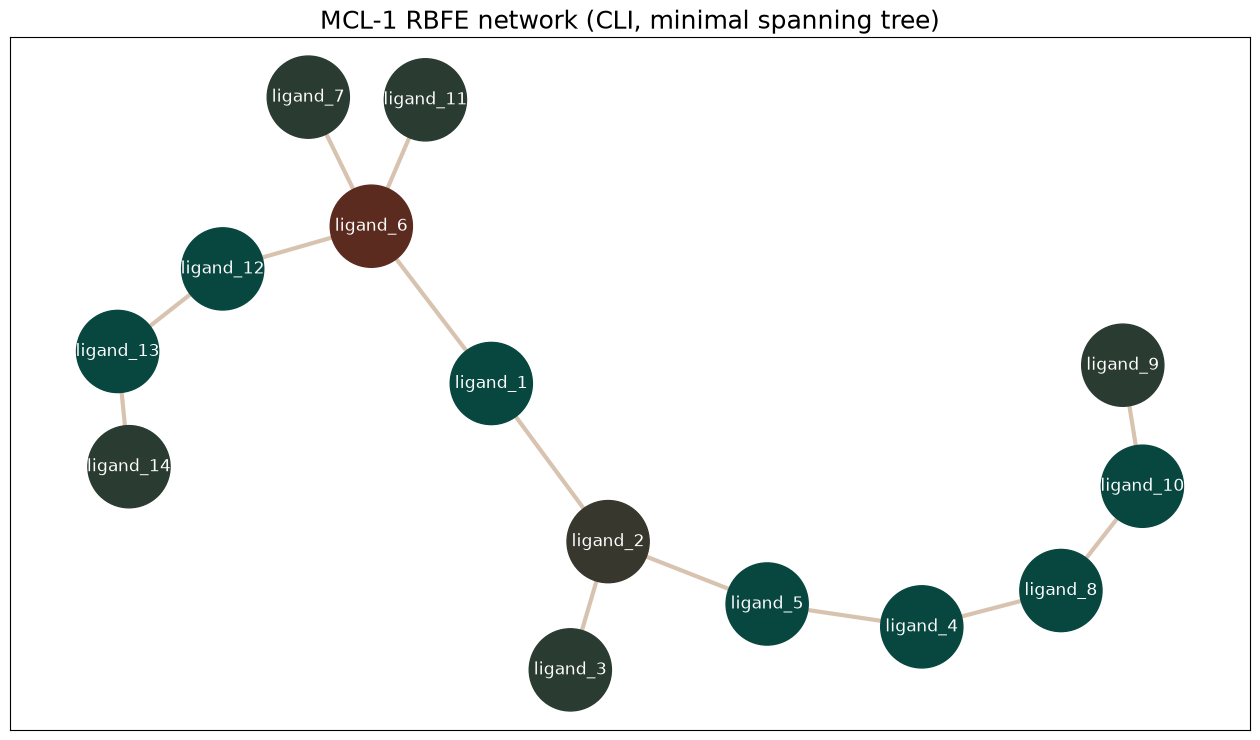

In [42]:
import openfe
import konnektor

with open("cli_output/network_setup/ligand_network.graphml") as f:
    cli_ligand_network = openfe.LigandNetwork.from_graphml(f.read())

display = konnektor.draw_ligand_network(cli_ligand_network, title="MCL-1 RBFE network (CLI, minimal spanning tree)", node_size=3500)

We can also look at the mappings for each transformation. This shows the atom correspondence, with the atoms in **red** being unique (i.e. either appearing or disappearing), and the atoms in **blue** being shared common atoms that change elements, every other atom is treated as a "core" atom which is interpolated directly between the two end states.

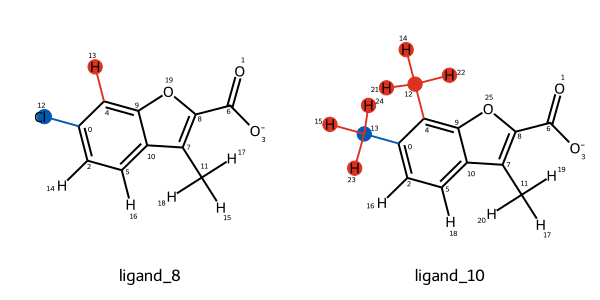

In [46]:
# our ligand network contains the mappings as edges
mappings = list(cli_ligand_network.edges)
mappings[0]

OpenFE also provides tooling to visualise the mappings in 3D!

The `view_3d` method displays the two ligands on the left and right and them overlapped in the middle. The coloured spheres on the ligands indicate the atom correspondence, i.e. two spheres of the same color across the left and right ligand mean that those two atoms are mapped. No coloured sphere means the atom is unique (i.e. will either be made to appear to disappear fully).

In [45]:
mappings[0].view_3d()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

<div style="background-color:#e8f5e9; border-left: 6px solid #4caf50; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

✏️ **Exercise**


Try looking at the different mappings in the network. You can do so by changing the index in the `mappings` list. E.g. `mappings[3]` will give you the fourth mapping.

</div>

### Step 3: Executing simulations

<div style="background-color:#fdecea; border-left: 6px solid #f44336; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

⚠️ **Note**


We are **not** going to run any simulations in this tutorial. Even at reduced settings, a single
RBFE leg takes far longer than we have time for here, and running 26 of them would need
substantial GPU resources.

Instead we will be providing you with precalculated data that you can load which are provided under `cli_output/results`.

</div>

The CLI `quickrun` command is used to execute simulations. Calling it on one of our transformation JSON files will automatically set up the molecular system (e.g. solvating, assigning the force field, creating the OpenMM inputs), run the simulation (usually requiring a GPU), and some limited post simulation analysis (e.g. MBAR matrix overlap, forward & reverse energy convergence analysis, protein backbone RMSD).

Here is an example of how you would call `quickrun` to run a single simulation:

```bash
openfe quickrun cli_output/network_setup/transformations/rbfe_ligand_1_solvent_ligand_2_solvent.json \
    -o results/rbfe_ligand_1_solvent_ligand_2_solvent.json \
    -d results/rbfe_ligand_1_solvent_ligand_2_solvent/
```

The `-o` flag indicates the file where the final output results file should be written. This is a JSON formatted file that contains key information about the simulation results such as the binding free energy estimate and the uncertainty.

The `-d` flag indicates where the simulation output files should be written, including the trajectory files, output PNGs of the automated analyses, etc...

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


See the [RBFE CLI tutorial](https://docs.openfree.energy/en/stable/tutorials/rbfe_cli_tutorial.html#run-the-simulations)
for more detail on running simulations, including a template for submitting simulations on a HPC machine.


</div>

An example output can be found under `cli_output/results/repeat0`. There we can look at the "rbfe_ligand_12_complex_ligand_13_complex" transformation.

In [102]:
!ls -ld cli_output/results/repeat0/rbfe_ligand_12_complex_ligand_13_complex*

drwxr-xr-x 6 ialibay ialibay    4096 Sep 18 13:25 cli_output/results/repeat0/rbfe_ligand_12_complex_ligand_13_complex
-rw-r--r-- 1 ialibay ialibay 1893197 Sep 18 13:25 cli_output/results/repeat0/rbfe_ligand_12_complex_ligand_13_complex.json


/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


As we can see, we have both a JSON file with our results and a directory where some of the simulation files are.

Looking inside the simulation files directory, you can see that we have:
- A **"shared_HybridTopologySetupUnit"** directory, which contains artifacts from how the system was set up, including an XML
  of the OpenMM system we created for simulation.
- A **"shared_HybridTopologyMultiStateSimulationUnit"** directory, which contains our simulation outputs, particularly our NetCDF trajectory `simulation.nc`.
- A **"shared_HybridTopologyMultiStateAnalysisUnit"** directory, which contains some of our automated analysis artifacts.

**Note:** some of our file names and directories contain a long alphanumeric string like "d45cad707529440a89a9e4e4b1853aeb", this is a unique identifier which openfe uses internally to track the simulation being executed.

**Note 2:** you will notice the word **"attempt_0"** in the directory names. By default `quickrun` will attempt to run a simulation up to 3 times if it fails. If that happens, the attempt number will increase, e.g. **"attempt_1"**.

In [104]:
!ls cli_output/results/repeat0/rbfe_ligand_12_complex_ligand_13_complex/*

cli_output/results/repeat0/rbfe_ligand_12_complex_ligand_13_complex/quickrun_cache:

cli_output/results/repeat0/rbfe_ligand_12_complex_ligand_13_complex/shared_HybridTopologyMultiStateAnalysisUnit-d45cad707529440a89a9e4e4b1853aeb_attempt_0:
forward_reverse_convergence.png  protein_2D_RMSD.png
ligand_COM_drift.png		 replica_exchange_matrix.png
ligand_RMSD.png			 replica_state_timeseries.png
mbar_overlap_matrix.png		 structural_analysis.npz

cli_output/results/repeat0/rbfe_ligand_12_complex_ligand_13_complex/shared_HybridTopologyMultiStateSimulationUnit-7ce34e9d956344db94e981650ac04e45_attempt_0:
checkpoint.chk	simulation.nc  simulation_real_time_analysis.yaml

cli_output/results/repeat0/rbfe_ligand_12_complex_ligand_13_complex/shared_HybridTopologySetupUnit-c692ca49a1b7415b8a5cf5513ea70e05_attempt_0:
A_db.json  hybrid_positions.npy  hybrid_system.xml.bz2
B_db.json  hybrid_system.pdb


/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


We can briefly look at some of the analysis PNGs we have created for this transformation.

First let's look at the MBAR overlap matrix, this tells us how well the different lambda states we simulated overlapped energetically. A value of less than 0.03 in the direct off diagonal would show poor overlap and therefore poor convergence.

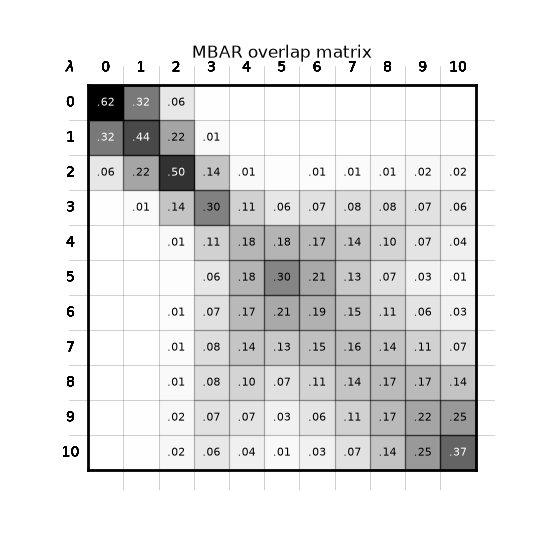

In [109]:
from IPython.display import Image

basepath="cli_output/results/repeat0/rbfe_ligand_12_complex_ligand_13_complex"

Image(filename=f"{basepath}/shared_HybridTopologyMultiStateAnalysisUnit-d45cad707529440a89a9e4e4b1853aeb_attempt_0/mbar_overlap_matrix.png")

Next we look at the ligand center-of-mass drift. This tells us how much the ligand has moved from its initial pose at the start of the production simulation. It offers a proxy for how dynamic the simulation was, large values (greater than 5 Angstrom) indicate a possibility that the ligand has moved out of the binding site.

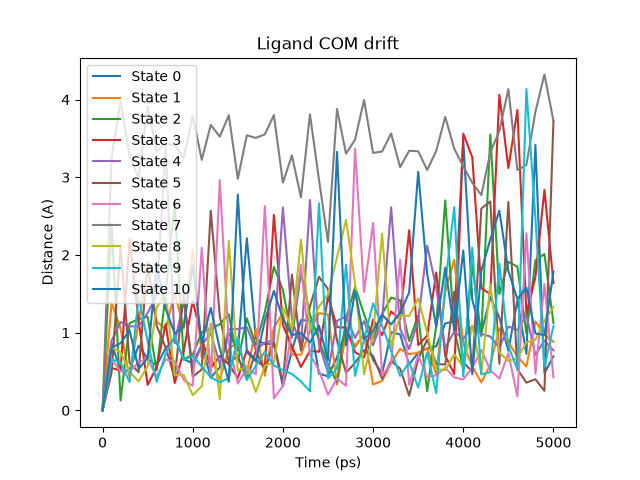

In [110]:
Image(filename=f"{basepath}/shared_HybridTopologyMultiStateAnalysisUnit-d45cad707529440a89a9e4e4b1853aeb_attempt_0/ligand_COM_drift.png")

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


You can find out more about the types of analyses the Hybrid Topology Protocol generates in the [OpenFE user guide](https://docs.openfree.energy/en/stable/guide/protocols/relativehybridtopology.html#analysis).


</div>

### Gathering results

Now that we have run all our simulations, we can gather our free energy results. This is done using the `openfe gather` command.

First let's start by gathering the "raw" results, that is the ΔG for every individual leg and repeat. All we have to do is pass the results JSON files to `openfe gather` with the `--report raw` flag:

In [105]:
!openfe gather --report raw cli_output/results/repeat?/*json

/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Loading results:  ▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇  78/78 files
/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/site-packages/openfecli/commands/gather.py:814: DeprecationWarning: 'click.utils.LazyFile' is deprecated and will be removed in Click 9.0.
  is_output_file = isinstance(output, click.utils.LazyFile)
┌─────────┬───────────┬───────────┬─────────────────────┬──────────────────────┐
│         │           │           │                     │ MBAR uncertainty     │
│ leg     │ ligand_i  │ ligand_j  │ DG(i->j) (kcal/mol) │ (kcal/mol)           │
├─────────┼───────────┼───────────┼─────────────────────┼──────────────────────┤
│ complex │ ligand_1  │ ligand_6  │ 31.3                │ 0.5                  │
│ complex │ ligand_1  │ ligand_6  │ 31.2                │ 0.5                  │
│ complex │ ligand_1  │ ligand_6  │ 31.1                │ 0.4                  │
│ solvent │ ligand_1  │ ligand_6  │ 31.0                │ 0.6                  │
│ solvent │

Next, let's look at the ΔΔG results, where we combine both legs of the thermodynamic cycle and average our results over the repeats.

**Note:** because we have multiple repeats, the uncertainty we report is the standard deviation in the estimate between repeats.

This can be done with the `--report ddg` flag:

In [106]:
!openfe gather --report ddg cli_output/results/repeat?/*json

/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Loading results:  ▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇  78/78 files
/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/site-packages/openfecli/commands/gather.py:814: DeprecationWarning: 'click.utils.LazyFile' is deprecated and will be removed in Click 9.0.
  is_output_file = isinstance(output, click.utils.LazyFile)
┌───────────┬───────────┬──────────────────────┬────────────────────────┐
│ ligand_i  │ ligand_j  │ DDG(i->j) (kcal/mol) │ uncertainty (kcal/mol) │
├───────────┼───────────┼──────────────────────┼────────────────────────┤
│ ligand_1  │ ligand_6  │ 0.3                  │ 0.2                    │
│ ligand_12 │ ligand_13 │ -0.8                 │ 0.3                    │
│ ligand_13 │ ligand_14 │ 0.28                 │ 0.09                   │
│ ligand_2  │ ligand_1  │ 2.5                  │ 0.4                    │
│ ligand_2  │ ligand_5  │ 0.5                  │ 0.2                    │
│ ligand_3  │ ligand_2  │ 1.40                 │ 0.06              

Finally, in some cases, it is useful to have an estimate for the absolute ΔG per ligand. In OpenFE, we can use a maximum likelihood estimator to generate these values from the ΔΔG values. This can be done with the `--report dG` flag.

**Important:** these absolute values are not true absolutes, instead they are relative to the mean of the ligands which is set to a ΔG value of 0 kcal/mol. If you want to compare these to experiment, you would need to shift them by the experimental value.

In [107]:
!openfe gather --report dg cli_output/results/repeat?/*json

/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Loading results:  ▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇  78/78 files
/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/site-packages/openfecli/commands/gather.py:814: DeprecationWarning: 'click.utils.LazyFile' is deprecated and will be removed in Click 9.0.
  is_output_file = isinstance(output, click.utils.LazyFile)
┌───────────┬────────────────────┬────────────────────────┐
│ ligand    │ DG(MLE) (kcal/mol) │ uncertainty (kcal/mol) │
├───────────┼────────────────────┼────────────────────────┤
│ ligand_1  │ 1.3                │ 0.2                    │
│ ligand_10 │ -0.8               │ 0.3                    │
│ ligand_11 │ -0.4               │ 0.4                    │
│ ligand_12 │ 2.4                │ 0.2                    │
│ ligand_13 │ 1.6                │ 0.3                    │
│ ligand_14 │ 1.9                │ 0.4                    │
│ ligand_2  │ -1.1               │ 0.2                    │
│ ligand_3  │ -2.5               │ 0.2                    │

In the API portion of this tutorial, we will demonstrate how you can go about plotting these results using our tool [Cinnabar](https://github.com/OpenFreeEnergy/cinnabar).

## The OpenFE Python API: running custom RBFE simulations

The CLI is convenient, but sometimes you need something it can't give you — a longer simulation,
a different force field, a non-default network topology. For that, we turn to the Python API.

In this section we will set up a similar campaign to the one we created with the CLI, but with
a few deliberate changes to demonstrate how you can use the API to customise simulations:

- A **redundant minimal spanning tree** network instead of a minimum spanning tree, giving us
  some redundancy to fall back on if an edge fails.
- **10 ns** of production simulation instead of the CLI's default 5 ns.
- **AshGC** partial charges together with the newest **OpenFF 2.3.0** force field
  (AshGC is the charge model OpenFF 2.3.0 was fitted against), instead of the default OpenFF 2.2.1 and AM1BCC charges.

### Step 1: Loading molecules

To create our simulations, we need objects which describe every part of the system.

OpenFE represents these as **`Component`s**; different portions of the system that
can be put composed together into a full chemical system (we'll meet the `ChemicalSystem` class itself shortly).

The first `Component` we will introduce is the `SmallMoleculeComponent`, which is geared specifically at holding
small molecules.

Let's reload our `ligands.sdf` file and create `SmallMoleculeComponent`s for every ligand:

In [48]:
import openfe
from rdkit import Chem

# Let's read our SDF file again
supplier = Chem.SDMolSupplier("inputs/ligands.sdf", removeHs=False)
ligand_rdmols = list(supplier)

# We then load every RDKit Molecule into a SmallMoleculeComponent.
ligands = [openfe.SmallMoleculeComponent.from_rdkit(mol) for mol in ligand_rdmols]

The main entry point for `SmallMoleculeComponent`s is an RDKit Molecule (in fact this is the main way we represent nearly all our molecules internally!). This is because RDKit Molecules include all the bond order and element information that we would need when doing operations such as mapping a transformation or assigning force field parameters.

`SmallMoleculeComponent`s, like some of our other `Components` have some built-in utilities. For example, you can get the total charge by calling the `total_charge` property:

In [51]:
ligands[0].total_charge

-1

To load the protein we use a `ProteinComponent`, which is made specifically for handling biopolymers.

With the `ProteinComponent`, we can directly load the PDB rather than going through a secondary object type. Our PDB parser is inherited from [OpenMM](https://openmm.org/), so we can load in any type of system that they can:

In [52]:
protein = openfe.ProteinComponent.from_pdb_file("inputs/protein.pdb")

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


Whilst our current PDB file only contains the protein, the `ProteinComponent` does support loading in crystallographic waters and ions. However it cannot handle loading in non-standard residues or small molecules.


</div>

`ProteinComponent` also have some useful utilities, for example you can convert them easily to OpenMM Topologies:

In [54]:
protein.to_openmm_topology()

<Topology; 1 chains, 153 residues, 2466 atoms, 2486 bonds>

Or get their position arrays in a format OpenMM will accept:

In [55]:
protein.to_openmm_positions()

[array([-18.585,  -3.46 ,   7.728]), array([-19.381,  -3.217,   7.146]), array([-18.517,  -2.802,   8.491]), array([-18.625,  -4.447,   7.954]), array([-17.349,  -3.23 ,   6.908]), array([-17.315,  -4.208,   6.439]), array([-16.364,  -3.115,   7.355]), array([-17.658,  -2.019,   5.997]), array([-18.624,  -1.936,   5.224]), array([-16.744,  -1.042,   6.083]), array([-15.985,  -1.168,   6.737]), array([-16.489,   0.018,   5.074]), array([-17.47 ,   0.419,   4.837]), array([-16.029,  -0.631,   3.742]), array([-15.421,   1.068,   5.573]), array([-14.559,   0.45 ,   5.843]), array([-15.767,   1.53 ,   6.498]), array([-14.866,  -1.115,   3.731]), array([-15.042,   2.075,   4.543]), array([-14.186,   2.942,   4.875]), array([-15.658,   2.222,   3.48 ]), array([-16.777,  -0.591,   2.606]), array([-17.667,  -0.115,   2.68 ]), array([-16.445,  -1.212,   1.378]), array([-16.162,  -2.234,   1.637]), array([-15.158,  -0.555,   0.715]), array([-17.63 ,  -1.154,   0.388]), array([-18.516,  -1.524,   

Finally, we have to define how our system will be solvated. To do this we use a `SolventComponent`. This object doesn't hold the positions of the water, but rather information about its composition.

For example here we explicitly build the default configuration for a `SolventComponent`, defining the solvent as water (`smiles='O'`), 'Cl-' as the negative counterion, 'Na+' as the positive counterion, a target ionic concentration of 0.15 M, and that the system will be neutralized:

In [58]:
# OpenFE uses OpenFF units when defining quantities
from openff.units import unit

solvent = openfe.SolventComponent(smiles='O', negative_ion='Cl-', positive_ion='Na+', ion_concentration=0.15 * unit.molar, neutralize=True)

This information will be used when we execute our transformation to build the system according to those specifications.

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


If you already have a pre-solvated, pre-equilibrated system (for example, one that includes a
membrane), you can use `SolvatedPDBComponent` or `ProteinMembraneComponent` instead of a separate
`ProteinComponent` + `SolventComponent` pair. See the
[OpenFE documentation](https://docs.openfree.energy/en/stable/) for more on preparing
membrane-containing systems.


</div>

### Step 2: Generating partial charges

Just like `openfe charge-molecules` on the CLI, the Python API has a function for bulk-assigning
partial charges: `bulk_assign_partial_charges`. Here we will use it to assign [AshGC charges, a
graph neural network charge model designed to reproduce AM1BCCELF10 charges quickly](https://pmc.ncbi.nlm.nih.gov/articles/PMC13173527/).
The AshGC model is distributed as the [OpenFF NAGL](https://github.com/openforcefield/openff-nagl) model `openff-gnn-am1bcc-1.0.0.pt`.

Here we use AshGC charges not only because they are high quality but also because this was the charge model OpenFF 2.3.0 (the force field we will be using) was fitted for.

In [60]:
from openfe.protocols.openmm_utils.charge_generation import bulk_assign_partial_charges

ligands = bulk_assign_partial_charges(
    molecules=ligands,
    overwrite=False,
    method="nagl",
    toolkit_backend="ambertools",
    generate_n_conformers=None,
    nagl_model="openff-gnn-am1bcc-1.0.0.pt",
    processors=4,
)

/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=85249) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=85249) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=85249) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=85249) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
Generating charges: 

As you can see AshGC charges are applied very quickly, much quicker than when we obtained AM1BCC charges with AmberTools earlier. This is one of the main advantages of AshGC charges; they avoid needing semi-empirical QM calculations, which can be very time consuming especially for larger molecules.

We can confirm the charges are attached by converting one of our SmallMoleculeComponents to an OpenFF `Molecule` and
inspecting its `partial_charges`:

In [61]:
offmol = ligands[0].to_openff()
offmol.partial_charges

Magnitude,[-0.16919414940125801 -0.7917311662698493 0.04118715730660102 -0.16368107738740303 -0.7917311662698493 -0.09985577556140282 -0.11444546523339608 0.9470113044714227 -0.04009212422020295 -0.052515289362739116 -0.12012286725289681 -0.04946974533445695 -0.09730458500630715 0.12086987254374168 0.12923848387949607 0.1255373483633294 0.12629924473517082]
Units,elementary_charge


### Step 3: Defining a network of ligand transformations

As mentioned earlier, in principle we could try to compute the free energy between
every possible pair of our 14 ligands. In practice, we don't want to because:

1. It scales as O(n²) in the number of ligands, which is prohibitively expensive once
   you have more than a handful.
3. Not every transformation would even succeed. Some ligand pairs are simply too different
   for a good hybrid topology mapping to exist. This is especially true for more complex
   ligand series where the transformations sometimes differ by more than just an R group
   transformation, or where the protein adapts around the ligands of interest.

Instead, we need to select a subset of transformations that we need to run. At the very minimum
this is a network that keeps every ligand **connected** to every other ligand, even if only indirectly.
This is required so that we can effectively calculate the relative free energy difference between any
two pairs of ligands in our series, which is possible even if we must calculate it through an indirect
route through the transformation of another ligand.

Selecting our network is a three-step process:
1. Choose an **atom mapper** that will be used to obtain the atom correspondence between our ligand pairs.
2. Choose a **scorer** for our atom mappings that will estimate the difficulty of the transformation.
3. Choose a **network planning algorithm** that will use the mapper and scorer to select desired transformations.

In the CLI, all three of these was automatically done by the `plan-rbfe-network` command.

#### Mapping two ligands

As mentioned earlier, in a hybrid topology RBFE, an atom mapping tells us which atoms are unique to each end-state
ligand (and so will appear or disappear over the simulation) and which are common to both (and so
will simply be interpolated between the two states).

In the CLI example above, this was done automatically with the [Kartograf](https://github.com/OpenFreeEnergy/kartograf) atom mapper. Kartograf is OpenFE's 3D-first mapper, which uses the ligands' 3D coordinates to build a mapping based on how close similar atoms are.
Let's use it directly via the Python API on a single pair of ligands:

INFO:	#################################
INFO:	Map Heavy Atoms 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	#################################
INFO:	Map Hydrogen Atoms: 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	Filtering bond breaks


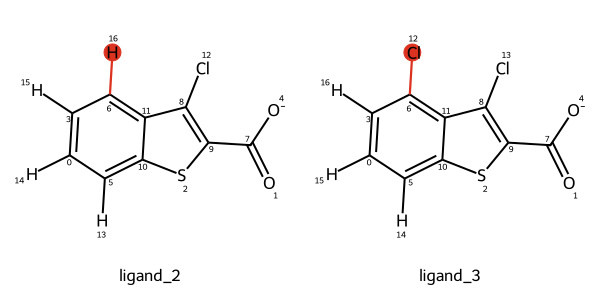

In [71]:
mapper = openfe.KartografAtomMapper()

# suggest_mappings returns a generator; Kartograf normally suggests a single mapping per pair
mapping = next(mapper.suggest_mappings(ligands[0], ligands[1]))
mapping

As a reminder, in our 2D descriptions, atoms unique to one ligand or the other (i.e. atoms that will appear/disappear) are highlighted in red and atoms that are mapped but change element are shown in blue. Atoms without a colour as mapped between the two ligands.

As we did earlier, we can also look at the same mapping in 3D:

In [63]:
mapping.view_3d()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

At its core, an `AtomMapping` object (which is what `mapping` contains) essentially holds a reference to the two ligands and how they are mapped. This can be accessed as a dictionary when calling `componentA_to_componentB`, where the keys are the atom indices of the first ligand, and the values the indices of the corresponding atoms in the second ligand. Any indices not in this dictionary are unique

In [69]:
mapping.componentA_to_componentB

{0: 0,
 1: 1,
 2: 2,
 3: 3,
 4: 4,
 5: 5,
 6: 6,
 7: 7,
 8: 8,
 9: 9,
 10: 10,
 11: 11,
 12: 13,
 13: 14,
 14: 15,
 15: 16,
 16: 12}

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


See the [Creating Atom Mapping](https://docs.openfree.energy/en/stable/guide/setup/creating_atom_mappings_and_scores.html) entry of the OpenFE user guide for more information on atom mappers.

</div>

<div style="background-color:#e8f5e9; border-left: 6px solid #4caf50; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

✏️ **Exercise**


OpenFE also ships a second atom mapper, `openfe.LomapAtomMapper`, which works by maximum common
substructure (MCS) search rather than 3D geometry.

Try mapping the same pair of ligands (`ligands[0]` and `ligands[1]`) with `LomapAtomMapper()`
instead of `KartografAtomMapper()`, and compare the resulting mapping to the Kartograf one above.
Do they map the same atoms? Why would they be different?

**Hint:** the `KartografAtomMapper` has automatically applied built-in [rules for filtering](https://kartograf.openfree.energy/en/latest/api/kartograf.filters.html) out some types of transformations which are deemed to usually cause issues.


</div>

#### Scoring two ligands

To decide which ligand pairs are worth simulating, we need some way to estimate up front how
*hard* a given transformation will be. This is done using an atom mapping **scorer**. A scorer
takes a `LigandAtomMapping` and returns a score from 0 (worst) to 1 (best).

Here we will use the LOMAP scorer (default scorer in OpenFE), which applies a set of empirical rules that penalise
transformations known to be difficult. For example, the LOMAP scorer penalises transformations
that involve large amounts of appearing/disappearing atoms or situations where the transformation
involves breaking open a ring. The full list of scorer rules can be found in the [LOMAP paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC3837551/).

Let's use the LOMAP scorer to score the mapping we created earlier:

In [72]:
score = openfe.lomap_scorers.default_lomap_score(mapping)
score

0.9048374180359595

The score of ~ 0.9 indicates that this is likely an easy transformation. The scorer is empirical and sometimes poorly estimates difficulty, but on average we find that it generally ends up being a good initial estimate of difficulty.

<div style="background-color:#e8f5e9; border-left: 6px solid #4caf50; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

✏️ **Exercise**


`openfe.lomap_scorers` has several other scoring functions beyond `default_lomap_score`, for
example `mcsr_score` (maximum common substructure size), `atomic_number_score`, and
`hybridization_score`. These are combined together in the `default_lomap_score`.

Try scoring the same `mapping` with one or two of these scoring functions. Do they
agree with `default_lomap_score` about how easy this transformation is?

**Hint:** you have to import the `lomap_scorers` module before you can use these scorers.

</div>

#### Creating ligand transformation networks

Finally, now that we have a mapper and a scorer, we need to generate the network of transformations
we want to simulate. We do this by creating a `LigandNetwork`.

In the CLI example, `plan-rbfe-network` automatically built a minimal spanning tree (MST), i.e. the
network with the fewest possible transformations that still connects every ligand. Here, we will instead
build a **redundant** MST, which ensures that each ligand is connected to at least two ligands (instead of one).

Building a `LigandNetwork` just requires the mapper and scorer we defined above, plus the ligands
we want in the network:

In [76]:
mapper = openfe.KartografAtomMapper()
scorer = openfe.lomap_scorers.default_lomap_score

ligand_network = openfe.ligand_network_planning.generate_minimal_redundant_network(
    ligands=ligands,
    mappers=[mapper],
    scorer=scorer,
    mst_num=2,  # make sure each ligand is at least connected to 2 other ligands
)

print(f"{len(ligand_network.nodes)} ligands, {len(ligand_network.edges)} edges")

INFO:	#################################
INFO:	Map Heavy Atoms 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	#################################
INFO:	Map Hydrogen Atoms: 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	Filtering bond breaks
INFO:	#################################
INFO:	Map Heavy Atoms 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	#################################
INFO:	Map Hydrogen Atoms: 
INFO:	#################################
INFO:	Masking Atoms
INFO:	Build Distance Matrix
INFO:	Calculate Mapping
INFO:	Find Maximal overlapping connected sets of mapped atoms
INFO:	Filtering 

14 ligands, 26 edges


Each edge in the network gives you back the two ligands involved and the mapping between them:

mapping:  {13: 13, 15: 15, 16: 16, 17: 17, 18: 18, 0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 19: 19}


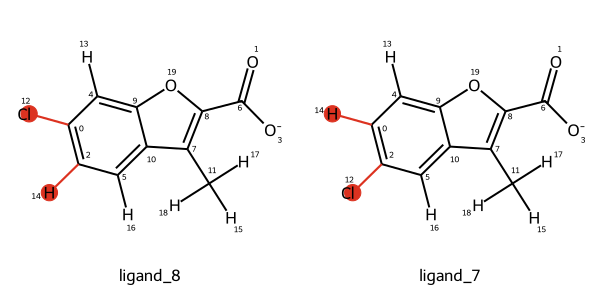

In [83]:
an_edge = next(iter(ligand_network.edges))
print("mapping: ", an_edge.componentA_to_componentB)
an_edge

<div style="background-color:#e8f5e9; border-left: 6px solid #4caf50; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

✏️ **Exercise**


Why would you choose to have a **redundant MST** instead of just simulating the minimum number
of edges possible?

</div>

Let's visualise the resulting network with konnektor, first as a static plot:

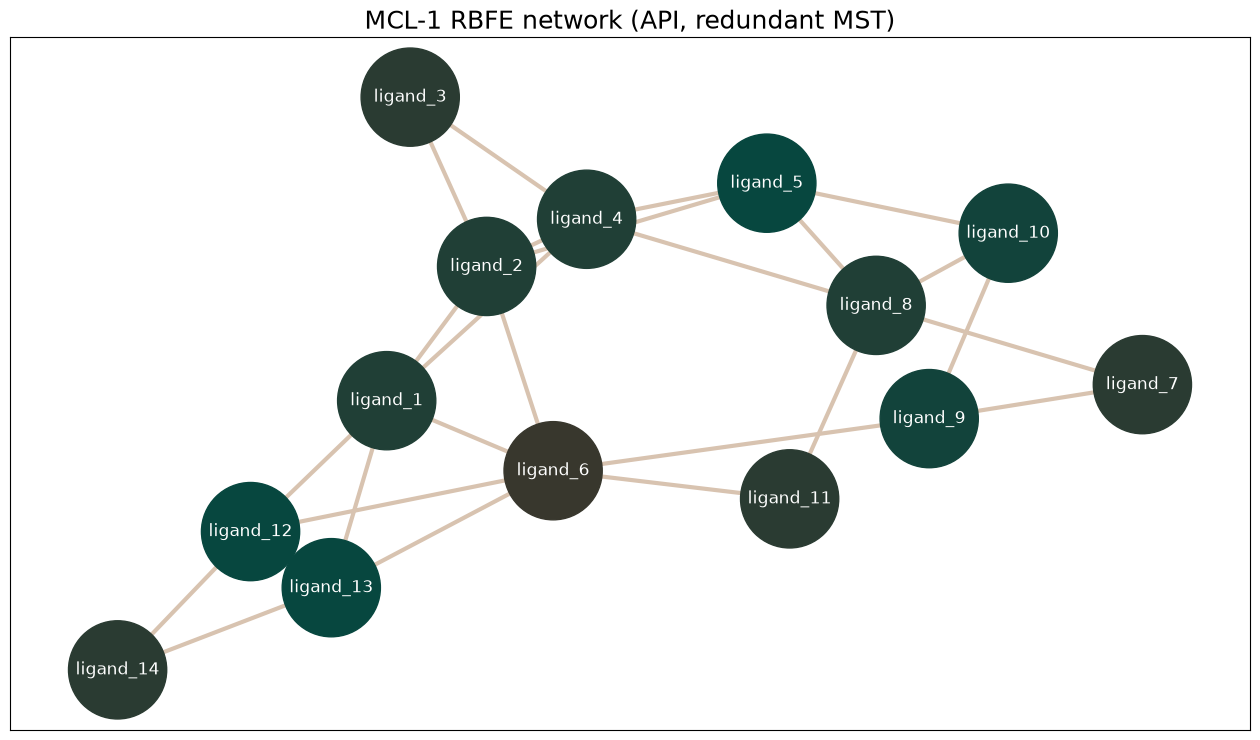

In [77]:
import konnektor

view = konnektor.draw_ligand_network(ligand_network, title="MCL-1 RBFE network (API, redundant MST)", node_size=5000)

Since the network is complicated, we also have an interactive widget where you can more easily see the transformations.

Note: you can zoom in and drag parts of the network around to see the connections.

In [79]:
from konnektor.visualization.widget import draw_network_widget

view = draw_network_widget(ligand_network, represent_molecules_twoD=True)

interactive(children=(Dropdown(description='layout', index=4, options=('dagre', 'cola', 'breadthfirst', 'conce…

<div style="background-color:#e8f5e9; border-left: 6px solid #4caf50; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

✏️ **Exercise**


Try building a couple of the other network topologies OpenFE offers, using the same `ligands`,
`mapper` and `scorer`:

- `openfe.ligand_network_planning.generate_minimal_spanning_network()`: a plain, non-redundant
  MST, this is what the CLI used above.
- `openfe.ligand_network_planning.generate_radial_network()`: a star network around one chosen ligand.
- `openfe.ligand_network_planning.generate_maximal_network()`: this just tries to connect every ligand to every other ligand.

Visualise each one with the `konnektor` utilities we demonstrated above.

In what situation would you want to run one network type over another?


</div>

### Step 4: Creating a `Protocol`

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


A `Protocol` is OpenFE's description of *how* to compute a free energy difference between two
end states (i.e. `ChemicalSystem`s). This includes; the sampling method, force field, simulation length,
and everything else needed to actually run and analyse the calculation. You can look at the [Protocol user guide entry](https://docs.openfree.energy/en/stable/guide/setup/defining_protocols.html) and the
[Choose and Configure a Protocol cookbook](https://docs.openfree.energy/en/stable/cookbook/choose_protocol.html) for more information, if needed.

</div>

The `RelativeHybridTopologyProtocol` is the OpenMM-based hybrid topology `Protocol` we have been using
throughout this tutorial.

The main input to a `Protocol` are settings, these will dictate how the `Protocol` will behave. We can
obtain a set of default settings for the `RelativeHybridTopologyProtocol` by calling its `default_settings` method:

In [84]:
from openfe.protocols.openmm_rfe import RelativeHybridTopologyProtocol

settings = RelativeHybridTopologyProtocol.default_settings()
settings

{'alchemical_settings': {'endstate_dispersion_correction': False,
                         'explicit_charge_correction': False,
                         'explicit_charge_correction_cutoff': {'unit': 'nanometer',
                                                               'val': 0.8},
                         'softcore_LJ': 'gapsys',
                         'softcore_alpha': 0.85,
                         'turn_off_core_unique_exceptions': True,
                         'use_dispersion_correction': False},
 'engine_settings': {'compute_platform': 'cuda', 'gpu_device_index': None},
 'forcefield_settings': {'constraints': 'hbonds',
                         'forcefields': ['amber/ff14SB.xml',
                                         'amber/tip3p_standard.xml',
                                         'amber/tip3p_HFE_multivalent.xml',
                                         'amber/phosaa10.xml',
                                         'amber/lipid17_merged.xml'],
                    

As you can see, there are quite a few things you can change, from how long the simulation will run (as defined in `simulation_settings`), to more obscure settings such as the softcore potential used in our alchemical transformation (as defined in `alchemical_settings`).

As mentioned earlier, in this exercise we want to:
- Run a longer production simulation (10 ns instead of the default 5 ns).
- Use the new OpenFF 2.3.0 force field for our ligand (instead of the default of OpenFF 2.2.1).

Here is how we can do this:

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**

OpenFE uses [OpenFF units](https://docs.openforcefield.org/projects/units/en/stable/), a derivative of [Pint](https://pint.readthedocs.io/en/stable/index.html), to define quantities such as time.

</div>

In [85]:
from openff.units import unit

# 10 ns of production instead of the default 5 ns
settings.simulation_settings.production_length = 10.0 * unit.nanosecond

# the newest force field, matched to the AshGC charges we generated above
settings.forcefield_settings.small_molecule_forcefield = "openff-2.3.0"

# we also set it to a single repeat per transformation to replicate the CLI's --n-protocol-repeats
# we can then execute the protocol multiple times to get repeats
settings.protocol_repeats = 1

# let's look at our new settings
settings

{'alchemical_settings': {'endstate_dispersion_correction': False,
                         'explicit_charge_correction': False,
                         'explicit_charge_correction_cutoff': {'unit': 'nanometer',
                                                               'val': 0.8},
                         'softcore_LJ': 'gapsys',
                         'softcore_alpha': 0.85,
                         'turn_off_core_unique_exceptions': True,
                         'use_dispersion_correction': False},
 'engine_settings': {'compute_platform': 'cuda', 'gpu_device_index': None},
 'forcefield_settings': {'constraints': 'hbonds',
                         'forcefields': ['amber/ff14SB.xml',
                                         'amber/tip3p_standard.xml',
                                         'amber/tip3p_HFE_multivalent.xml',
                                         'amber/phosaa10.xml',
                                         'amber/lipid17_merged.xml'],
                    

Next we need to adapt our settings to the type of transformation we will be doing since
solvent and complex transformations usually need slightly different settings. For
example, the complex leg doesn't need as much water padding around it, since most of the box is
already filled by the protein.

Rather than set this by hand, we can reuse the same helper the CLI
uses internally, `RelativeHybridTopologyProtocol._adaptive_settings`, which adapts a settings
object based on the `ChemicalSystem`s and mapping it will be used for.

<div style="background-color:#fdecea; border-left: 6px solid #f44336; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

⚠️ **Note**


Here we create a single set of complex and solvent settings & Protocols for all our ligand transformations.
This is because all the transformations are very similar. If they were to change substantially, e.g. if some
involve net charge changes and other did not, you would need to create a set of Protocols per transformation type.

</div>

First, let's start by defining a `ChemicalSystem` for an example transformation.

A `ChemicalSystem` is a container that holds all the `Component`s that define one of the end states.
For a complex transformation, this usually holds:
- A `SmallMoleculeComponent`: the ligand that is transforming.
- A `ProteinComponent`: the protein the ligand is bound to.
- A `SolventComponent`: how the system will be solvated.

For a solvent transformation, it would be the same except without the `ProteinComponent`.

With this information, the `Protocol` can then not only understand how to build the system but also identify which parts of the system are changing.

Now let's create some ChemicalSystems for the complex & solvent transformations for the first edge in our ligand network:

In [87]:
# Extract the first mapping in the network
mapping = next(iter(ligand_network.edges))

# We can then construct the complex ChemicalSystems
stateA_complex = openfe.ChemicalSystem(
    {
        "ligand": mapping.componentA, # This is the SmallMoleculeComponent stored as state A in the mapping
        "protein": protein, # This is the ProteinComponent we loaded much earlier in this tutorial
        "solvent": solvent, # Similarly this is the SolventComponent we create a while back
    }
)

stateB_complex = openfe.ChemicalSystem(
    {
        "ligand": mapping.componentB, # This is the only thing that changes from stateA_complex
        "protein": protein,
        "solvent": solvent,
    }
)

# Now the solvent ChemicalSystems - the only thing that changes is the lack of ProteinComponent
stateA_solvent = openfe.ChemicalSystem(
    {
        "ligand": mapping.componentA,
        "solvent": solvent,
    }
)

stateB_solvent = openfe.ChemicalSystem(
    {
        "ligand": mapping.componentB,
        "solvent": solvent,
    }
)

Now we can use these `ChemicalSystem`s to adapt our settings for the type of solvent & complex transformations that we have in our network:

In [88]:
complex_settings = RelativeHybridTopologyProtocol._adaptive_settings(
    stateA=stateA_complex,
    stateB=stateB_complex,
    mapping=mapping,
    initial_settings=settings, # These are the settings we manually ammended earlier
)

solvent_settings = RelativeHybridTopologyProtocol._adaptive_settings(
    stateA=stateA_solvent,
    stateB=stateB_solvent,
    mapping=mapping,
    initial_settings=settings,
)

# Let's look at what happens to our solvent padding
print("solvent leg padding:", solvent_settings.solvation_settings.solvent_padding)
print("complex leg padding:", complex_settings.solvation_settings.solvent_padding)

solvent leg padding: 1.5 nanometer
complex leg padding: 1 nanometer


Finally, with settings for both our solvent and complex transformations, let's create our two `Protocol`s:

In [89]:
solvent_protocol = RelativeHybridTopologyProtocol(solvent_settings)
complex_protocol = RelativeHybridTopologyProtocol(complex_settings)

### Step 5: Creating `Transformation`s

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


A `Transformation` ties everything together into a single "simulation ready" object:
- Two `ChemicalSystem`s defining the start and end states.
- An `AtomMapping` defining the atom correspondence.
- The `Protocol` defining the type of simulation and its settings.

It's the object we eventually write to file and hand to `openfe quickrun`.

</div>

Just as with the CLI, every ligand pair (every edge in our network) needs **two**
`Transformation`s, one for the solvent leg, one for the complex leg.

Let's demonstrate this for a single ligand pair first, before doing it for the whole network. We will re-use the mapping & `ChemicalSystem`s we built in the previous section:

In [93]:
solvent_transformation = openfe.Transformation(
    stateA_solvent,
    stateB_solvent,
    solvent_protocol,
    mapping=mapping,
    # It's usually a good idea to give it a descriptive name so that we know what the transformation is
    name=f"rbfe_{mapping.componentA.name}_solvent_{mapping.componentB.name}_solvent",
)

complex_transformation = openfe.Transformation(
    stateA_complex,
    stateB_complex,
    complex_protocol,
    mapping=mapping,
    # It's usually a good idea to give it a descriptive name so that we know what the transformation is
    name=f"rbfe_{mapping.componentA.name}_complex_{mapping.componentB.name}_complex",
)

# Let's print out the names of each Transformation
print("solvent: ", solvent_transformation.name, "complex: ", complex_transformation.name)

solvent:  rbfe_ligand_8_solvent_ligand_7_solvent complex:  rbfe_ligand_8_complex_ligand_7_complex


Now let's do this for every edge in the network, creating a list of `Transformation`s:

In [94]:
# We create a dictionary that holds the different Components that
# we need to use for each type of transformation
legs = {
    "solvent": {"solvent": solvent},
    "complex": {"solvent": solvent, "protein": protein},
}

# Similarly, this dictionary holds the protocol for each leg
protocols = {"solvent": solvent_protocol, "complex": complex_protocol}

transformations = []
for mapping in ligand_network.edges:
    for leg, shared_components in legs.items():
        # We use ** to unpack the contents of the dictionary
        stateA = openfe.ChemicalSystem({"ligand": mapping.componentA, **shared_components})
        stateB = openfe.ChemicalSystem({"ligand": mapping.componentB, **shared_components})
        name = f"rbfe_{mapping.componentA.name}_{leg}_{mapping.componentB.name}_{leg}"
        transformations.append(
            openfe.Transformation(stateA, stateB, protocols[leg], mapping=mapping, name=name)
        )

print(f"{len(transformations)} transformations")

52 transformations


<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


Whilst not used here, you can also create an `AlchemicalNetwork` by passing it a list of `Transformation`s.
This offers the ability to explore your `Transformation`s in a single object and is also the starting point
for more advanced functionality in OpenFE tooling.

</div>

### Step 6: Writing `Transformation`s to file

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


Nearly every OpenFE object (`LigandNetwork`, `Transformation`, `AlchemicalNetwork`, `Protocol`, and more) can be written
to a JSON file with `.to_json()` and read back with `.from_json()`.

</div>

To actually run our campaign, we need to write each `Transformation` out to its own JSON file, so
that it can be picked up by `openfe quickrun`:

In [99]:
import pathlib

# We will write our transformations inside of a dictionary named "transformations" inside of "api_outputs"
transformation_dir = pathlib.Path("api_output/transformations")
transformation_dir.mkdir(exist_ok=True, parents=True)

# Finally we write out all the transformations based on their names
for transformation in network.edges:
    transformation.to_json(transformation_dir / f"{transformation.name}.json")

!ls api_output/transformations

rbfe_ligand_12_complex_ligand_13_complex.json
rbfe_ligand_12_complex_ligand_14_complex.json
rbfe_ligand_12_solvent_ligand_13_solvent.json
rbfe_ligand_12_solvent_ligand_14_solvent.json
rbfe_ligand_13_complex_ligand_14_complex.json
rbfe_ligand_13_solvent_ligand_14_solvent.json
rbfe_ligand_1_complex_ligand_12_complex.json
rbfe_ligand_1_complex_ligand_13_complex.json
rbfe_ligand_1_complex_ligand_6_complex.json
rbfe_ligand_1_solvent_ligand_12_solvent.json
rbfe_ligand_1_solvent_ligand_13_solvent.json
rbfe_ligand_1_solvent_ligand_6_solvent.json
rbfe_ligand_2_complex_ligand_1_complex.json
rbfe_ligand_2_complex_ligand_5_complex.json
rbfe_ligand_2_complex_ligand_6_complex.json
rbfe_ligand_2_solvent_ligand_1_solvent.json
rbfe_ligand_2_solvent_ligand_5_solvent.json
rbfe_ligand_2_solvent_ligand_6_solvent.json
rbfe_ligand_3_complex_ligand_2_complex.json
rbfe_ligand_3_complex_ligand_4_complex.json
rbfe_ligand_3_solvent_ligand_2_solvent.json
rbfe_ligand_3_solvent_ligand_4_solvent.json
rbfe_ligand_4_co

/home/ialibay/software/mambaforge/install/envs/openfe_demo/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=85249) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


### Executing our simulations

<div style="background-color:#fdecea; border-left: 6px solid #f44336; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

⚠️ **Note**


As with the CLI section, we won't run any of these simulations here, 52 transformations
(26 edges × 2 legs) at 10 ns of production each is well beyond what we can do in a tutorial
session. Precalculated results are present under `api_output/results`.


</div>

While it is possible to manually execute simulations via the Python API, these are complicated and overly clunky. So we recommend using the `quickrun` CLI command to do this instead, like we did earlier.

### Analysing results

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


This subsection (and the two below it) are placeholders: they describe what you would do once
you've actually run the campaign above.

Once we have results, we can show off the same gather functionality as earlier and then look at:

</div>

#### Looking at structural data

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


Here we demonstrate how we can read in the simulaltion results into an MDAnalysis Universe and analyze things.

</div>

#### Looking at networks of free energies using cinnabar

<div style="background-color:#d9edf7; border-left: 6px solid #2196F3; padding: 12px 16px; border-radius: 4px; margin: 10px 0;">

💡 **Info**


Here we demonstrate how we can use cinnabar to analyze our results.


</div>

## Review & Conclusions

In this notebook we've planned two RBFE campaigns for the same MCL-1 fragment series:

- With the **OpenFE CLI**, in four commands (`charge-molecules`, `plan-rbfe-network`, `quickrun`, and `gather`),
  using our best-practice defaults throughout.
- With the **OpenFE Python API**, customising the atom mapper, network topology, partial charge
  method, force field, and simulation length.

Applying these tools to your own systems can be as easy as swapping out the `ligands.sdf` and `protein.pdb` files! Try it out!